# Demonstrate how to load Casual MNIST dataset

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from pathlib import Path
import os
import math
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from ciflows.datasets.multidistr import StratifiedSampler
from ciflows.datasets.causalmnist import CausalDigitBarMNIST
from ciflows.datasets.causalmnist_scm.scm import (
    alter_digitbar_img,
    causal_mnist_scm,
    alter_digitbar_style_img,
)
from ciflows.datasets.causalmnist import CausalMNIST

import torch
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
import torchvision
from torchvision.datasets import MNIST
from torchvision.utils import save_image

In [3]:
def show_imgs(imgs, title=None, row_size=4, ytick_labels=None):
    # Form a grid of pictures (we use max. 8 columns)
    num_imgs = imgs.shape[0] if isinstance(imgs, torch.Tensor) else len(imgs)
    is_int = (
        imgs.dtype == torch.int32
        if isinstance(imgs, torch.Tensor)
        else imgs[0].dtype == torch.int32
    )
    nrow = min(num_imgs, row_size)
    ncol = int(math.ceil(num_imgs / nrow))
    imgs = torchvision.utils.make_grid(imgs, nrow=nrow, pad_value=128 if is_int else 0.5)
    np_imgs = imgs.cpu().numpy()
    # Plot the grid
    fig, ax = plt.subplots(figsize=(1.5 * nrow, 1.5 * ncol))
    plt.imshow(np.transpose(np_imgs, (1, 2, 0)), interpolation="nearest")
    # plt.axis("off")
    plt.axis("on")
    ax.set_xticks([])
    if title is not None:
        plt.title(title)

    if ytick_labels is not None:
        print(nrow, ncol)
        ax.set_yticks([(i + 0.5) * imgs.shape[1] / ncol for i in range(ncol)])
        ax.set_yticklabels(ytick_labels[:ncol])
    # plt.show()
    # plt.close()
    return fig, ax

# First load in MNIST and alter some images

In [10]:
root = Path("/Users/adam2392/pytorch_data/")
img_size = 32

# set up transforms for each image to augment the dataset
transform = torchvision.transforms.Compose(
    [
        transforms.Resize((img_size, img_size)),  # Resize images to 128x128
        transforms.CenterCrop(img_size),  # Ensure square crop
        torchvision.transforms.ToTensor(),
    ]
)
mnist_data = MNIST(root, train=True, download=True, transform=transform)

images = mnist_data.data
labels = mnist_data.targets

In [19]:
# generate a dictionary of causal labels for each SCM
scm_causal_labels = dict()
graph_type = 'chain'

for intervention_idx in range(4):
    causal_labels = causal_mnist_scm(intervention_idx, labels, graph_type=graph_type)

    print([len(val) for val in causal_labels.values()])
    scm_causal_labels[intervention_idx] = causal_labels

[60000, 60000, 60000, 60000]
[60000, 60000, 60000, 60000]
[60000, 60000, 60000, 60000]
[60000, 60000, 60000, 60000]


## Plot distributions of the SCM

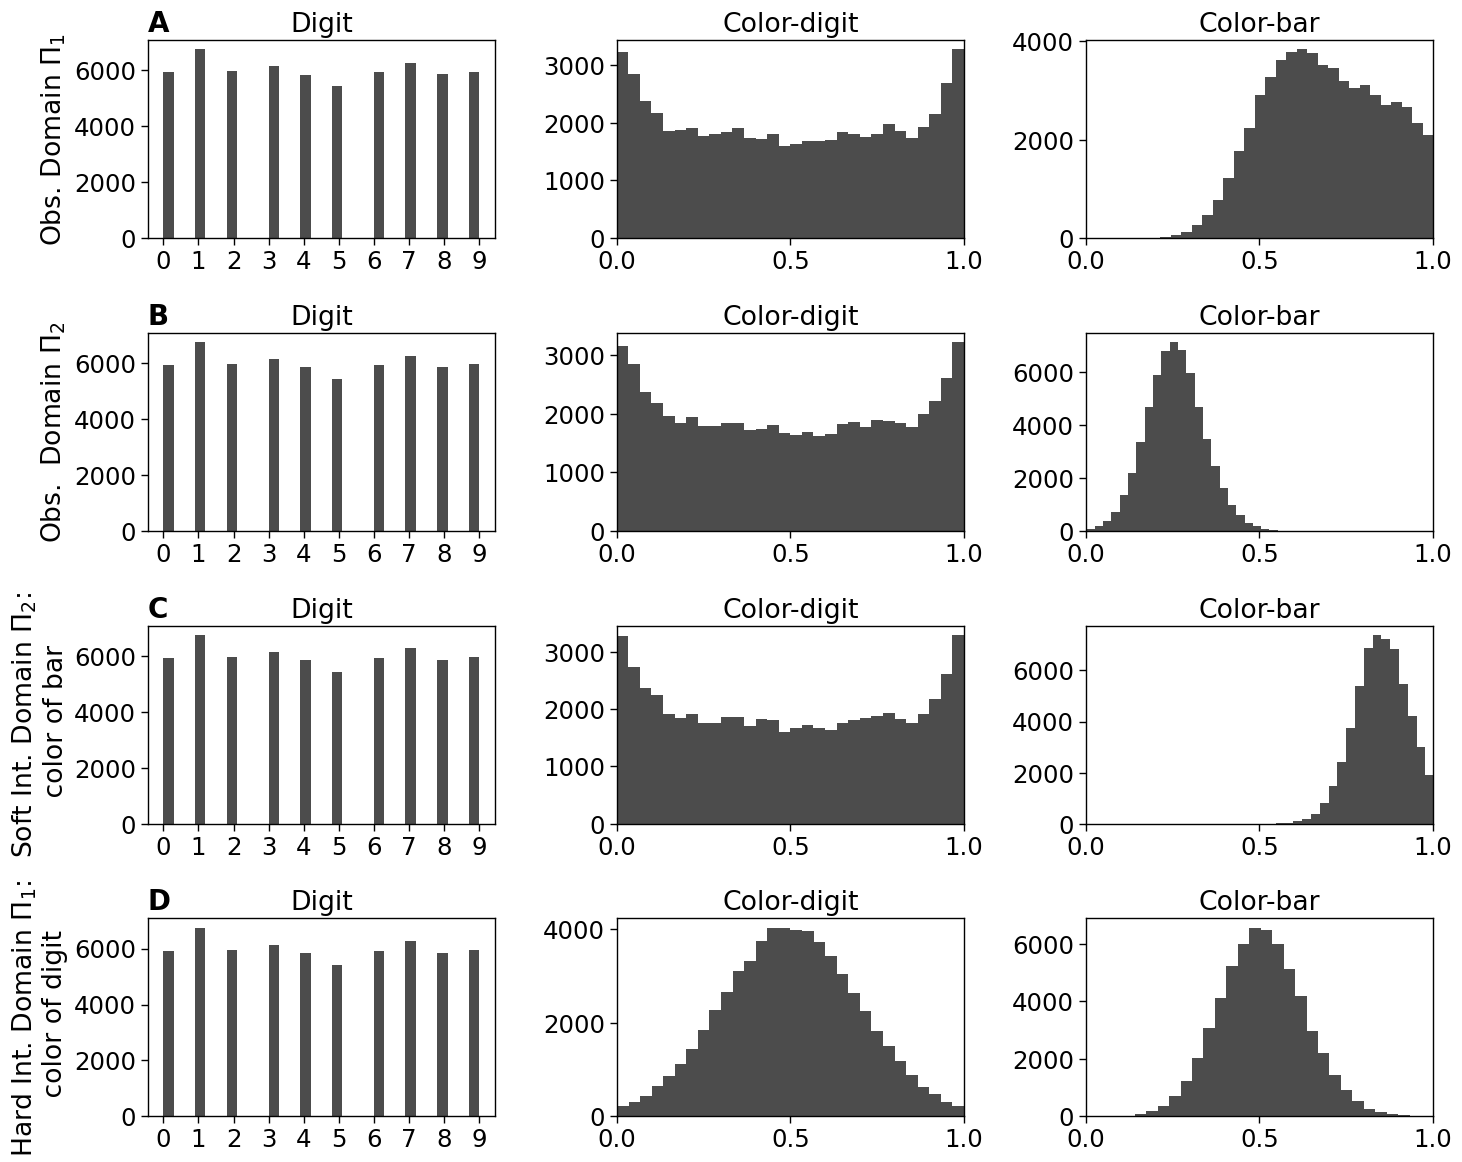

In [20]:
sns.set_context("paper", font_scale=2.0)

# Plotting the distributions
fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=False, sharey=False)
row_labels = ["A", "B", "C", "D"]
for idx in range(4):
    causal_labels = scm_causal_labels[idx]
    if idx == 0:
        setting = "Obs. Domain $\Pi_1$"
    elif idx == 1:
        setting = "Obs.  Domain $\Pi_2$"
    elif idx == 2:
        setting = "Soft Int. Domain $\Pi_2$:\n color of bar"
    elif idx == 3:
        setting = "Hard Int. Domain $\Pi_1$:\n color of digit"
    # axes[idx, 0].set_ylabel(f"{setting}")
    axes[idx, 0].set_ylabel(f"{setting}")

    digit = causal_labels["digit"]
    color_digit = causal_labels["color_digit"]
    color_bar = causal_labels["color_bar"]

    axes[idx, 0].hist(digit, bins=30, color="black", alpha=0.7)
    axes[idx, 0].set_title(f"Digit")
    axes[idx, 0].set_xticks(range(10))
    axes[idx, 1].hist(color_digit, bins=30, color="black", alpha=0.7)
    axes[idx, 1].set_title(f"Color-digit")
    axes[idx, 1].set_xlim([0, 1])
    axes[idx, 1].set_xticks([0, 0.5, 1])
    axes[idx, 2].hist(color_bar, bins=30, color="black", alpha=0.7)
    axes[idx, 2].set_title(f"Color-bar")
    axes[idx, 2].set_xlim([0, 1])
    axes[idx, 2].set_xticks([0, 0.5, 1])

    # Set the letter as the title of the [idx, 0] figure and position it to the top-right
    axes[idx, 0].set_title(row_labels[idx], loc="left", fontsize=20, fontweight="bold")

plt.tight_layout()
# fig.savefig(
#     "/Users/adam2392/Downloads/mnist-colorbar-distributions.pdf", bbox_inches="tight"
# )
plt.show()

# Apply changes to the dataset

In [21]:
img_dataset = []
labels_dataset = None

for intervention_idx in [0, 1, 2, 3]:
    causal_labels = scm_causal_labels[intervention_idx]
    causal_labels["distr_idx"] = torch.tensor([intervention_idx] * len(labels))

    for idx, img in enumerate(images):
        color_bar = causal_labels["color_bar"][idx]
        color_digit = causal_labels["color_digit"][idx]

        new_img = alter_digitbar_img(img, color_digit, color_bar, cmap="gist_rainbow", dtype="PIL")
        img_dataset.append(new_img)

        # Uncomment to show the images
        if idx >= 7:
            break

img_dataset = torch.vstack(
    [
        # torchvision.transforms.functional.pil_to_tensor(x).reshape(1, 3, 28, 28) 
        transform(x).reshape(1, 3, img_size, img_size)
        for x in img_dataset]
)
print(img_dataset.shape)

torch.Size([32, 3, 32, 32])


torch.Size([32, 3, 32, 32])
8 4


Text(0.5, 0.98, 'Samples From Dataset')

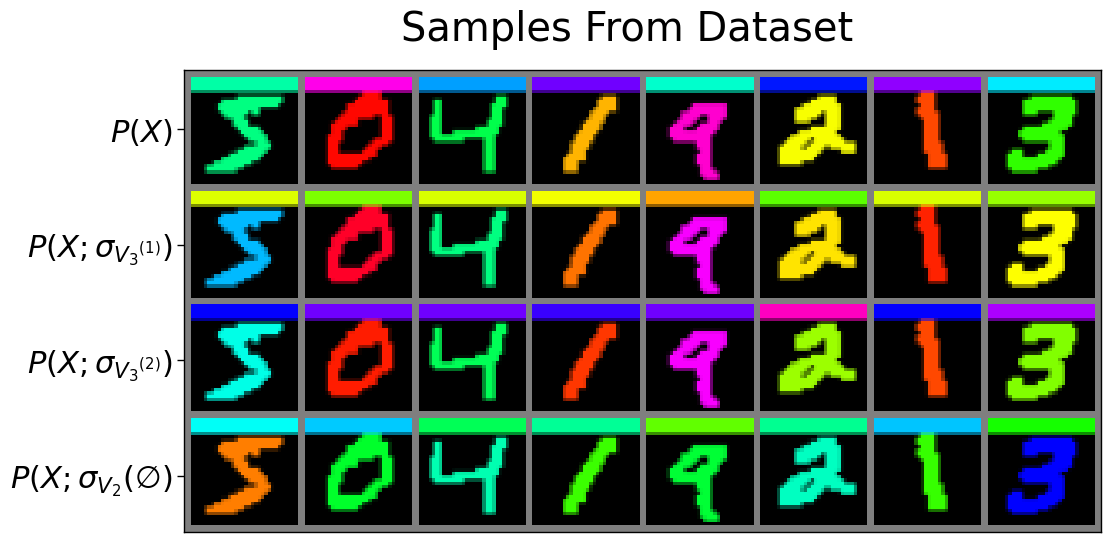

In [22]:
print(img_dataset.shape)
sns.set_context("paper", font_scale=2.5)
fig, ax = show_imgs(
    img_dataset,
    row_size=8,
    ytick_labels=[
        r"$P(X)$",
        r"$P(X; \sigma_{{V_3}^{(1)}})$",
        r"$P(X; \sigma_{{V_3}^{(2)}})$",
        r"$P(X; \sigma_{V_2}(\emptyset)$",
    ],
)
fig.suptitle(
    "Samples From Dataset",
    #   x=0.6, y=0.9
)
# fig.savefig("/Users/adam2392/Downloads/sample_dataset.pdf", bbox_inches="tight")

## Generate the dataset

In [24]:
keys = ["width", "color_digit", "color_bar", "label", "distr_idx"]
# print(pd.DataFrame({key: causal_labels[key] for key in keys}))
# print(causal_labels)
print(len(causal_labels))


5


In [25]:
target_name_map = {
    0: 'observational',
    1: 'color_bar',
    2: 'color_bar',
    3: 'color_digit',
}
save_dir_name = {
    0: 'observational',
    1: 'int_colorbar_0',
    2: 'int_colorbar_1',
    3: 'int_colordigit_0',
}
# save each dataset
for intervention_idx in [0, 1, 2, 3]:
    img_dataset = []

    causal_labels = scm_causal_labels[intervention_idx]
    # causal_labels["distr_idx"] = torch.tensor([intervention_idx] * len(labels))
    intervention_target_tensor = torch.tensor(causal_labels["intervention_targets"], dtype=torch.int)
    # intervention_target_tensor = torch.zeros((len(causal_labels), 3), dtype=torch.int)

    # extract the meta-data from the causal labels
    keys = ["digit", "color_digit", "color_bar"]
    label_tensor = torch.zeros((len(intervention_target_tensor), len(keys)))
    # convert the labels from a list of dictionaries to a tensor array
    for idx, key in enumerate(keys):
        label_tensor[:, idx] = torch.tensor(causal_labels[key])
    distr_idx = torch.tensor([intervention_idx] * len(intervention_target_tensor), dtype=torch.int)
    label_tensor = torch.hstack([label_tensor, distr_idx.reshape(-1, 1)])
    labels_df = pd.DataFrame(label_tensor, columns=keys + ["distr_idx"])
    labels_df['intervention'] = target_name_map[intervention_idx]
    labels_df[['digit', 'distr_idx']] = labels_df[['digit','distr_idx']].astype(int)

    for idx, img in enumerate(images):
        color_bar = causal_labels["color_bar"][idx]
        color_digit = causal_labels["color_digit"][idx]

        new_img = alter_digitbar_img(img, color_digit, color_bar, cmap="gist_rainbow", dtype="PIL")
        img_dataset.append(new_img)

    img_dataset = torch.vstack(
        [
            # torchvision.transforms.functional.pil_to_tensor(x).reshape(1, 3, 28, 28)]
            transform(x).reshape(1, 3, img_size, img_size)
            for x in img_dataset
        ]
    )

    distr_dir_name = save_dir_name[intervention_idx]

    # save the actual data to disc now
    imgs_fname = root / "CausalMNIST" / graph_type / distr_dir_name / "imgs.pt"
    meta_data_fname = root / "CausalMNIST" / graph_type /distr_dir_name / "causal_attrs.csv"
    targets_fname = root / "CausalMNIST" / graph_type / distr_dir_name / "targets.pt"
    imgs_fname.parent.mkdir(exist_ok=True, parents=True)

    torch.save(img_dataset, imgs_fname)
    torch.save(intervention_target_tensor, targets_fname)
    labels_df.to_csv(meta_data_fname, index=False)

print(img_dataset.shape)
print(intervention_target_tensor.shape)
print(label_tensor.shape)
display(labels_df.head())

print(img_dataset.shape)
# print(labels_dataset.keys())

/var/folders/6_/sl83qtkd68x3_mvfys07_6qm0000gn/T/ipykernel_41515/262737693.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  intervention_target_tensor = torch.tensor(causal_labels["intervention_targets"], dtype=torch.int)
/var/folders/6_/sl83qtkd68x3_mvfys07_6qm0000gn/T/ipykernel_41515/262737693.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label_tensor[:, idx] = torch.tensor(causal_labels[key])
/var/folders/6_/sl83qtkd68x3_mvfys07_6qm0000gn/T/ipykernel_41515/262737693.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  interv

torch.Size([60000, 3, 32, 32])
torch.Size([60000, 3])
torch.Size([60000, 4])


,digit,color_digit,color_bar,distr_idx,intervention
0,5,0.489813,0.599582,3,color_digit
1,0,0.415463,0.793868,3,color_digit
2,4,0.289234,0.821644,3,color_digit
3,1,0.579230,0.530525,3,color_digit
4,9,0.091585,0.905322,3,color_digit


torch.Size([60000, 3, 32, 32])


# Sample random distribution of images

In [7]:
dataset = CausalMNIST(root, graph_type)

In [8]:
print(len(dataset.data), len(dataset.intervention_targets), len(dataset.causal_attrs))

240000 240000 240000


In [15]:
# write dataloader
loader = DataLoader(
    dataset=dataset,
    batch_size=32,
    shuffle=True,
    num_workers=1,
)

print(len(dataset))
for idx, (img, distr_idx, target, meta_label) in enumerate(loader):
    print(img.shape)
    print(distr_idx.shape)
    print(target.shape)
    print(meta_label.shape)
    break

240000
torch.Size([32, 3, 28, 28])
torch.Size([32])
torch.Size([32, 3])
torch.Size([32, 4])


torch.Size([32, 3, 28, 28])
8 4


Text(0.5, 0.98, 'Samples From Dataset')

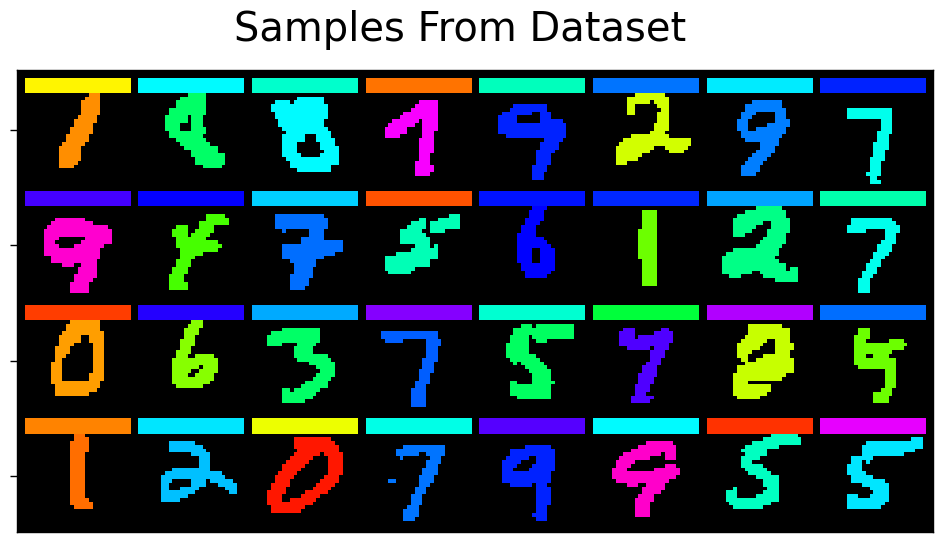

In [13]:
print(img.shape)
sns.set_context("paper", font_scale=2.5)
fig, ax = show_imgs(
    img,
    row_size=8,
    ytick_labels=[]#["Obs", "Int. Color-Bar", "Int. Color-Bar", "Int. Color-Digit"],
)
fig.suptitle("Samples From Dataset",
            #   x=0.6, y=0.9
              )
# fig.savefig("/Users/adam2392/Downloads/sample_dataset.pdf", bbox_inches="tight")

# MorphoMNIST to apply style changes to the actual images

In [43]:
from ciflows.datasets.causalmnist_scm.perturb import Thinning, Thickening
from ciflows.datasets.causalmnist_scm.morpho import ImageMorphology

In [84]:
# generate a dictionary of causal labels for each SCM
scm_causal_labels = dict()
graph_type = 'chain_style'

for intervention_idx in range(4):
    causal_labels = causal_mnist_scm(intervention_idx, labels, graph_type=graph_type)

    print([len(val) for val in causal_labels.values()])
    scm_causal_labels[intervention_idx] = causal_labels

[60000, 60000, 60000, 60000, 60000]
[60000, 60000, 60000, 60000, 60000]
[60000, 60000, 60000, 60000, 60000]
[60000, 60000, 60000, 60000, 60000]


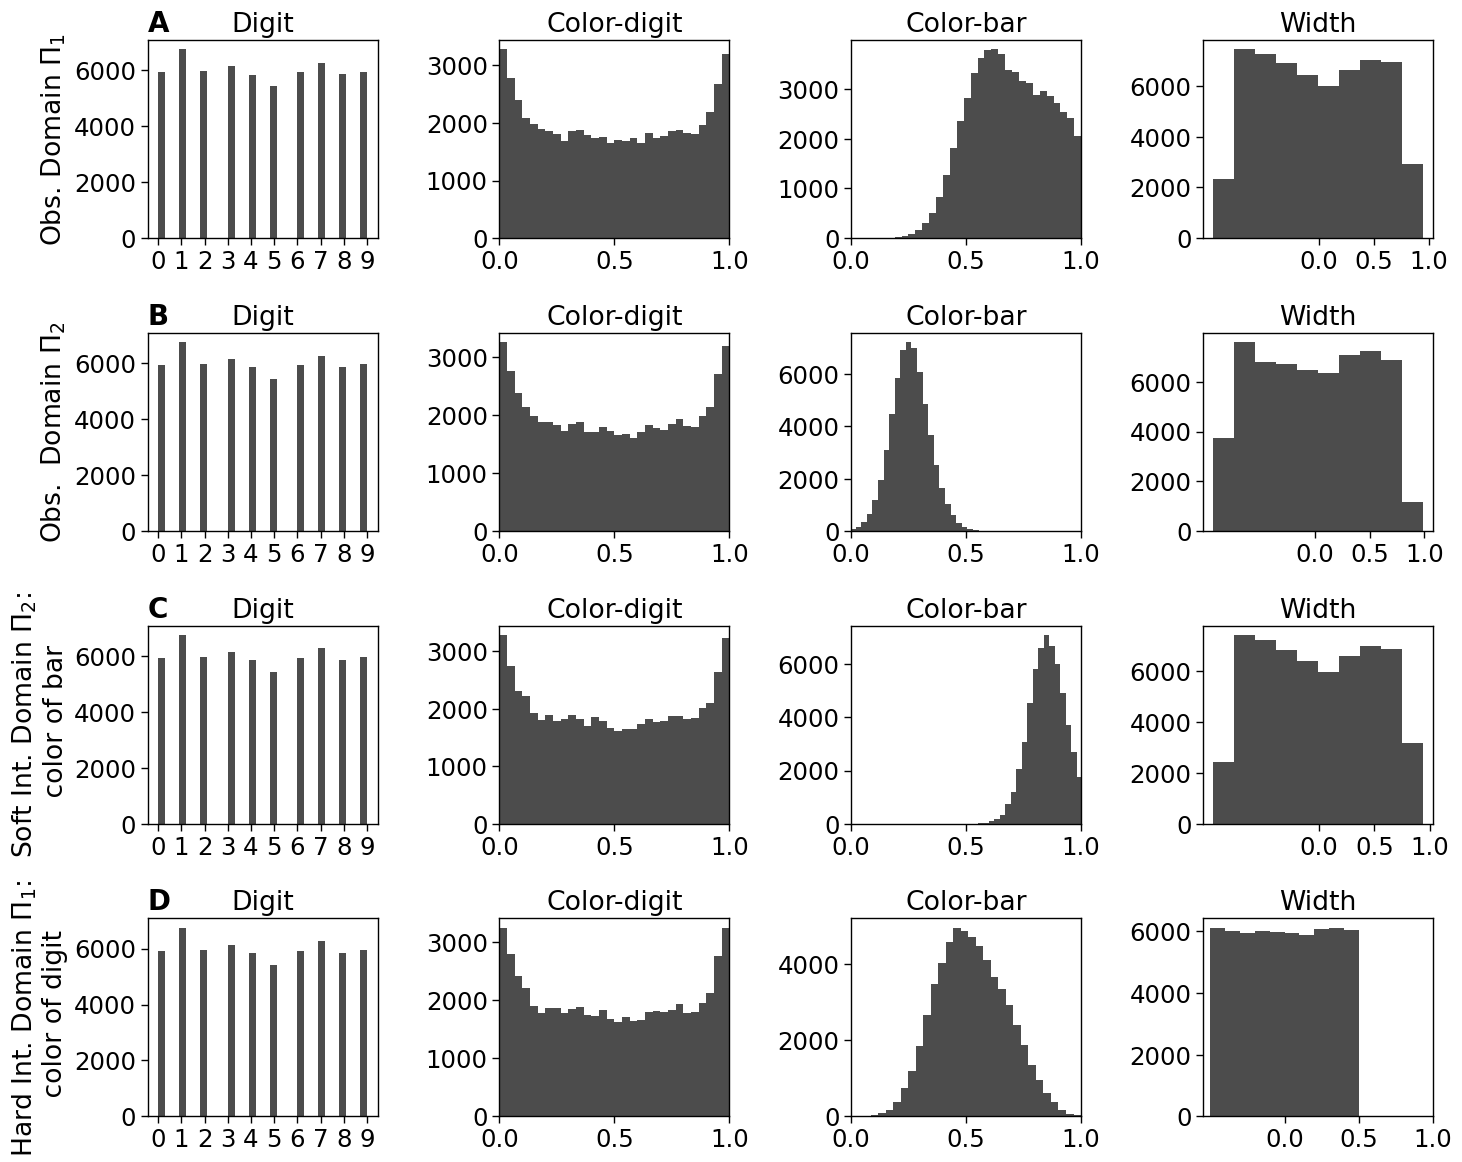

In [85]:
sns.set_context("paper", font_scale=2.0)

# Plotting the distributions
fig, axes = plt.subplots(4, 4, figsize=(15, 12), sharex=False, sharey=False)
row_labels = ["A", "B", "C", "D", "E"]
for idx in range(4):
    causal_labels = scm_causal_labels[idx]
    if idx == 0:
        setting = "Obs. Domain $\Pi_1$"
    elif idx == 1:
        setting = "Obs.  Domain $\Pi_2$"
    elif idx == 2:
        setting = "Soft Int. Domain $\Pi_2$:\n color of bar"
    elif idx == 3:
        setting = "Hard Int. Domain $\Pi_1$:\n color of digit"
    # axes[idx, 0].set_ylabel(f"{setting}")
    axes[idx, 0].set_ylabel(f"{setting}")

    digit = causal_labels["digit"]
    color_digit = causal_labels["color_digit"]
    color_bar = causal_labels["color_bar"]
    width = causal_labels['width']

    axes[idx, 0].hist(digit, bins=30, color="black", alpha=0.7)
    axes[idx, 0].set_title(f"Digit")
    axes[idx, 0].set_xticks(range(10))
    axes[idx, 1].hist(color_digit, bins=30, color="black", alpha=0.7)
    axes[idx, 1].set_title(f"Color-digit")
    axes[idx, 1].set_xlim([0, 1])
    axes[idx, 1].set_xticks([0, 0.5, 1])
    axes[idx, 2].hist(color_bar, bins=30, color="black", alpha=0.7)
    axes[idx, 2].set_title(f"Color-bar")
    axes[idx, 2].set_xlim([0, 1])
    axes[idx, 2].set_xticks([0, 0.5, 1])

    axes[idx, 3].hist(width, color="black", alpha=0.7)
    axes[idx, 3].set_title(f"Width")
    # axes[idx, 3].set_xlim([0, 1])
    axes[idx, 3].set_xticks([0, 0.5, 1])

    # Set the letter as the title of the [idx, 0] figure and position it to the top-right
    axes[idx, 0].set_title(row_labels[idx], loc="left", fontsize=20, fontweight="bold")

plt.tight_layout()
# fig.savefig(
#     "/Users/adam2392/Downloads/mnist-colorbar-distributions.pdf", bbox_inches="tight"
# )
plt.show()

In [97]:
img_dataset = []
labels_dataset = None

for intervention_idx in [0, 1, 2, 3]:
    causal_labels = scm_causal_labels[intervention_idx]
    causal_labels["distr_idx"] = torch.tensor([intervention_idx] * len(labels))

    for idx, img in enumerate(images):
        color_bar = causal_labels["color_bar"][idx]
        color_digit = causal_labels["color_digit"][idx]
        width = causal_labels["width"][idx]

        new_img = alter_digitbar_style_img(img, width, color_digit, color_bar, cmap="gist_rainbow", dtype="PIL")
        img_dataset.append(new_img)

        # Uncomment to show the images
        if idx >= 7:
            break

img_dataset = torch.vstack(
    [
        # torchvision.transforms.functional.pil_to_tensor(x).reshape(1, 3, 28, 28) 
        transform(x).reshape(1, 3, img_size, img_size)
        for x in img_dataset]
)
print(img_dataset.shape)

torch.Size([32, 3, 32, 32])


torch.Size([32, 3, 32, 32])
8 4


Text(0.5, 0.98, 'Samples From Dataset')

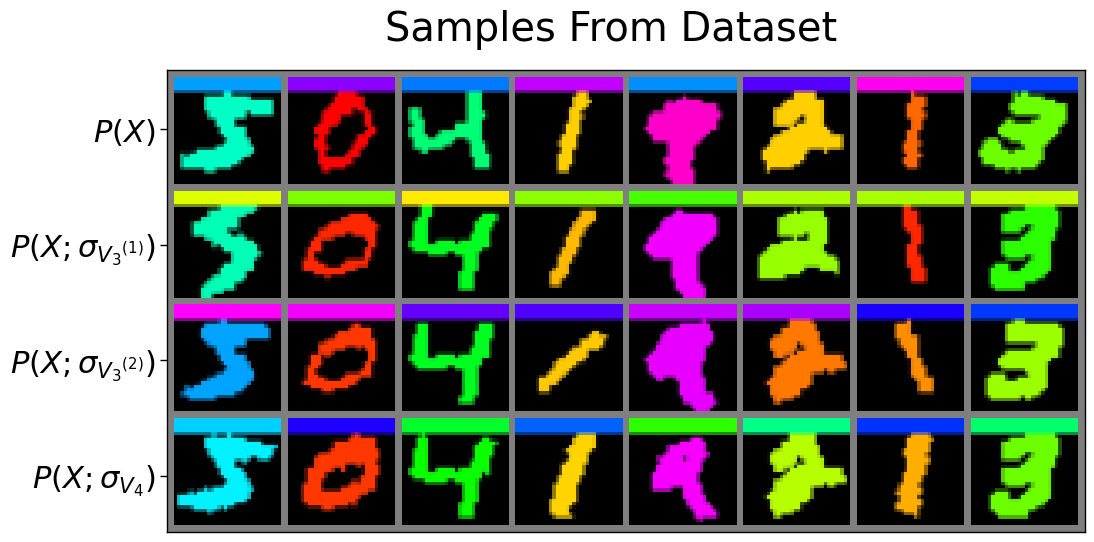

In [98]:
print(img_dataset.shape)
sns.set_context("paper", font_scale=2.5)
fig, ax = show_imgs(
    img_dataset,
    row_size=8,
    ytick_labels=[
        r"$P(X)$",
        r"$P(X; \sigma_{{V_3}^{(1)}})$",
        r"$P(X; \sigma_{{V_3}^{(2)}})$",
        r"$P(X; \sigma_{V_4})$",
    ],
)
fig.suptitle(
    "Samples From Dataset",
    #   x=0.6, y=0.9
)
# fig.savefig("/Users/adam2392/Downloads/sample_dataset.pdf", bbox_inches="tight")